# XGBoost — Optuna Hyperparameter Tuning (GPU-ready)

Same data pipeline / CV / sample weights as `xgboost.ipynb`. Detects CUDA and uses `device='cuda'` if available; falls back to CPU otherwise.

Current XGB CPU baseline: **0.92377 ± 0.00944** AUC.

## Imports

In [1]:
import pandas as pd
import numpy as np
import warnings, json
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

import xgboost as xgb
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold

from common import *

print('xgboost:', xgb.__version__)
print('optuna: ', optuna.__version__)

xgboost: 3.2.0
optuna:  4.8.0


## Detect GPU

In [2]:
# XGBoost will raise if device='cuda' isn't usable, so probe a tiny fit first.
def gpu_available():
    try:
        m = XGBClassifier(n_estimators=1, tree_method='hist', device='cuda', verbosity=0)
        m.fit(np.array([[0.0],[1.0]]), np.array([0,1]))
        return True
    except Exception as e:
        print('GPU probe failed:', repr(e)[:160])
        return False

USE_GPU = gpu_available()
DEVICE = 'cuda' if USE_GPU else 'cpu'
print('device:', DEVICE)

device: cuda


## Load + preprocess (mirror of `xgboost.ipynb`)

In [3]:
train_df = pd.read_csv('archive/train.csv')
test_df  = pd.read_csv('archive/test.csv')
orig_df  = pd.read_csv('archive/f1_strategy_dataset_v4.csv')

df = (train_df
        .pipe(copy_data)
        .pipe(clean_data)
        .pipe(remove_duplicates)
        .pipe(make_new_features))

orig_df_cleaned = (orig_df
        .pipe(copy_data)
        .pipe(clean_data)
        .pipe(remove_duplicates)
        .pipe(make_new_features))

train_df_length = df.shape[0]
df = pd.concat([df, orig_df_cleaned])
if 'normalized_tyrelife' in df.columns:
    df = df.drop('normalized_tyrelife', axis=1)
df = df.reset_index(drop=True)

sample_weights = np.ones(df.shape[0])
sample_weights[train_df_length:] = 1.25

target = get_target()
features = get_features(df)
categorical_features = ['compound', 'race', 'year_cat']
df[categorical_features] = df[categorical_features].astype('category')

X, y = df[features], df[target]
groups = (df['race'].astype(str) + '_' + df['year'].astype(str)).values
strat_y = (df['pitnextlap'].astype(str) + '_' + df['year'].astype(str))

print(df.shape, 'rows /', len(features), 'features')

(540511, 15) rows / 14 features


## Optuna objective

5-fold StratifiedGroupKFold during search, with early stopping inside each fold.

In [4]:
TUNE_N_SPLITS = 5
SEED = 42

def objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'device': DEVICE,
        'enable_categorical': True,
        'n_estimators': 3000,
        'early_stopping_rounds': 50,
        'n_jobs': -1,
        'random_state': 123,
        'verbosity': 0,
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth':        trial.suggest_int('max_depth', 4, 12),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 200.0, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel':trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'gamma':            trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        'reg_alpha':        trial.suggest_float('reg_alpha',  1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'max_bin':          trial.suggest_categorical('max_bin', [128, 256, 512]),
    }

    sgkf = StratifiedGroupKFold(n_splits=TUNE_N_SPLITS, shuffle=True, random_state=123)
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X, strat_y, groups=groups)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = XGBClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False,
            sample_weight=sample_weights[tr_idx],
        )
        proba = model.predict_proba(X_val)[:, 1]
        fold_scores.append(roc_auc_score(y_val, proba))

        trial.report(float(np.mean(fold_scores)), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))

## Run study

Enqueue the current baseline first so we never regress.

In [5]:
N_TRIALS = 80
TIMEOUT_SEC = 60 * 60 * 4

baseline_params = {
    'learning_rate':     0.3,
    'max_depth':         6,
    'min_child_weight':  1.0,
    'subsample':         1.0,
    'colsample_bytree':  1.0,
    'colsample_bylevel': 1.0,
    'gamma':             1e-8,
    'reg_alpha':         1e-8,
    'reg_lambda':        1.0,
    'max_bin':           256,
}

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
    study_name='xgb_f1_pit',
)
study.enqueue_trial(baseline_params)
study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT_SEC, show_progress_bar=True, gc_after_trial=True)

print('best AUC (5-fold):', round(study.best_value, 5))
print('best params:', study.best_params)

[I 2026-05-27 18:54:52,822] A new study created in memory with name: xgb_f1_pit


  0%|          | 0/80 [00:00<?, ?it/s]

[I 2026-05-27 18:55:02,326] Trial 0 finished with value: 0.9201205934611687 and parameters: {'learning_rate': 0.3, 'max_depth': 6, 'min_child_weight': 1.0, 'subsample': 1.0, 'colsample_bytree': 1.0, 'colsample_bylevel': 1.0, 'gamma': 1e-08, 'reg_alpha': 1e-08, 'reg_lambda': 1.0, 'max_bin': 256}. Best is trial 0 with value: 0.9201205934611687.
[I 2026-05-27 18:56:05,757] Trial 1 finished with value: 0.9277066573225143 and parameters: {'learning_rate': 0.02757359293934948, 'max_depth': 12, 'min_child_weight': 48.343714531846395, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'colsample_bylevel': 0.5779972601681014, 'gamma': 3.200866785899844e-08, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598, 'max_bin': 512}. Best is trial 1 with value: 0.9277066573225143.
[I 2026-05-27 18:56:20,623] Trial 2 finished with value: 0.9235203006542921 and parameters: {'learning_rate': 0.09528587217040241, 'max_depth': 5, 'min_child_weight': 2.6205032550962546, 

## Study summary

In [6]:
trials_df = study.trials_dataframe(attrs=('number', 'value', 'state', 'params', 'duration'))
trials_df = trials_df.sort_values('value', ascending=False)
trials_df.head(15)

,number,value,state,params_colsample_bylevel,params_colsample_bytree,params_gamma,params_learning_rate,params_max_bin,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,duration
23,23,0.929686,COMPLETE,0.636439,0.520349,2.435935e-07,0.017826,256,12,3.511040,0.002170,1.355536e-06,0.855235,0 days 00:01:37.826683
40,40,0.929401,COMPLETE,0.830141,0.515784,4.186203e-07,0.010842,256,11,10.628198,0.000868,2.976662e-06,0.831709,0 days 00:01:51.616226
64,64,0.929284,COMPLETE,0.572957,0.517279,3.194371e-07,0.010752,256,12,1.206031,0.000068,2.453911e-06,0.839779,0 days 00:02:54.382063
73,73,0.929280,COMPLETE,0.646566,0.584278,2.168409e-07,0.011610,512,11,9.091416,0.192542,2.801747e-03,0.917561,0 days 00:01:54.134582
52,52,0.929278,COMPLETE,0.630408,0.557824,5.377180e-08,0.019448,512,11,5.146431,0.202081,4.960248e-04,0.946191,0 days 00:01:17.686384
37,37,0.929232,COMPLETE,0.567875,0.514375,1.919308e-08,0.024339,256,12,11.849745,0.000349,3.907928e-07,0.807056,0 days 00:01:12.840326
27,27,0.929065,COMPLETE,0.516521,0.513729,3.378810e-08,0.010748,128,12,8.313968,0.000046,1.639225e-07,0.777172,0 days 00:02:04.384154
29,29,0.929058,COMPLETE,0.562487,0.546852,4.817795e-08,0.011642,128,12,4.751433,0.000011,3.188925e-05,0.664453,0 days 00:01:52.547831
77,77,0.929034,COMPLETE,0.562778,0.563083,3.379583e-07,0.020370,512,12,9.469925,4.720232,8.265553e-04,0.925185,0 days 00:01:40.409664
57,57,0.928989,COMPLETE,0.542741,0.593118,1.013167e-08,0.012572,256,11,4.414694,0.000101,1.532498e-07,0.737044,0 days 00:01:41.871869


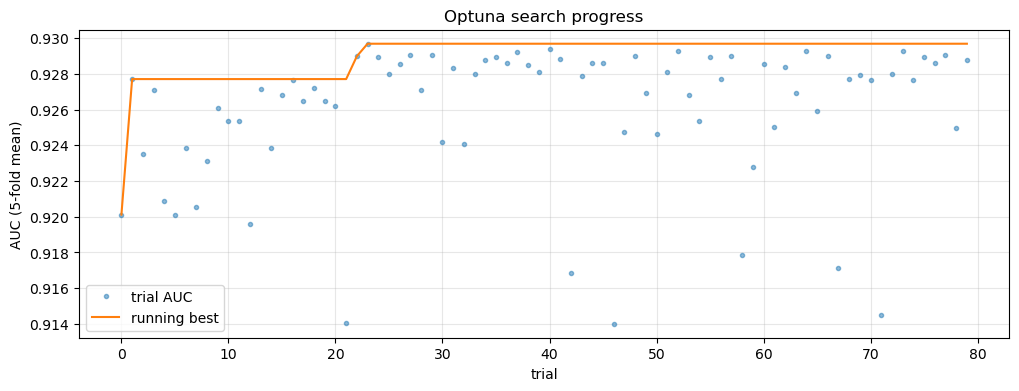

In [7]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.figsize'] = (12, 4)

vals = [t.value for t in study.trials if t.value is not None]
running_best = np.maximum.accumulate(vals)
plt.plot(vals, '.', alpha=0.5, label='trial AUC')
plt.plot(running_best, label='running best')
plt.xlabel('trial')
plt.ylabel('AUC (5-fold mean)')
plt.legend(); plt.grid(alpha=0.3); plt.title('Optuna search progress'); plt.show()

## Validate best params on the full 10-fold CV

In [8]:
best_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'device': DEVICE,
    'enable_categorical': True,
    'n_estimators': 3000,
    'early_stopping_rounds': 50,
    'n_jobs': -1,
    'random_state': 123,
    'verbosity': 0,
    **study.best_params,
}

sgkf_full = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=123)
scores, best_iters = [], []
oof_preds = np.zeros(len(df))

for fold, (tr_idx, val_idx) in enumerate(sgkf_full.split(X, strat_y, groups=groups)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = XGBClassifier(**best_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False,
        sample_weight=sample_weights[tr_idx],
    )
    proba = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = proba
    score = roc_auc_score(y_val, proba)
    scores.append(score)
    best_iters.append(model.best_iteration)
    print(f'Fold {fold}: AUC={score:.5f}  best_iter={model.best_iteration}')

print(f'\nMean AUC: {np.mean(scores):.5f} ± {np.std(scores):.5f}')
print(f'Mean best_iter: {int(np.mean(best_iters))}  Max best_iter: {int(np.max(best_iters))}')

oof_train = oof_preds[:train_df_length]
y_train_arr = y.iloc[:train_df_length].values
print(f'OOF AUC (train portion): {roc_auc_score(y_train_arr, oof_train):.5f}')

Fold 0: AUC=0.91929  best_iter=1344
Fold 1: AUC=0.92239  best_iter=629
Fold 2: AUC=0.94330  best_iter=650
Fold 3: AUC=0.92555  best_iter=982
Fold 4: AUC=0.94363  best_iter=681
Fold 5: AUC=0.94152  best_iter=882
Fold 6: AUC=0.93626  best_iter=1035
Fold 7: AUC=0.93096  best_iter=1125
Fold 8: AUC=0.93203  best_iter=1271
Fold 9: AUC=0.92212  best_iter=1069

Mean AUC: 0.93171 ± 0.00875
Mean best_iter: 966  Max best_iter: 1344
OOF AUC (train portion): 0.93516


In [10]:
final_params = {k: v for k, v in best_params.items() if k != 'early_stopping_rounds'}
final_params['n_estimators'] = int(np.max(best_iters) * 1.10)

xgb_final_model = XGBClassifier(**final_params)
xgb_final_model.fit(X, y, sample_weight=sample_weights)
print('trained final model with n_estimators =', final_params['n_estimators'])

trained final model with n_estimators = 1478


In [12]:
with open('./archive/xgb_best_params.json', 'w') as f:
    json.dump({
        'best_params': study.best_params,
        'best_value_5fold': study.best_value,
        'mean_auc_10fold': float(np.mean(scores)),
        'std_auc_10fold':  float(np.std(scores)),
        'best_iters': [int(b) for b in best_iters],
        'device': DEVICE,
    }, f, indent=2)
print('saved ./archive/xgb_best_params.json')

saved ./archive/xgb_best_params.json
